# GPU Password Cracker — HPC Course Project

**Make sure GPU is enabled:** Runtime → Change runtime type → GPU (T4)

This notebook:
1. Checks your GPU
2. Writes and compiles the CUDA cracker
3. Runs brute-force, dictionary, and rule-based attacks
4. Benchmarks GPU vs CPU and plots results

In [1]:
# Cell 1: Verify GPU is available
!nvidia-smi
!nvcc --version

Fri Apr 24 15:17:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Cell 2: Write md5.cuh — the GPU MD5 implementation
%%writefile md5.cuh
#pragma once
#include <stdint.h>

#define MD5_S11 7
#define MD5_S12 12
#define MD5_S13 17
#define MD5_S14 22
#define MD5_S21 5
#define MD5_S22 9
#define MD5_S23 14
#define MD5_S24 20
#define MD5_S31 4
#define MD5_S32 11
#define MD5_S33 16
#define MD5_S34 23
#define MD5_S41 6
#define MD5_S42 10
#define MD5_S43 15
#define MD5_S44 21

#define MD5_F(x,y,z) (((x)&(y))|((~x)&(z)))
#define MD5_G(x,y,z) (((x)&(z))|((y)&(~z)))
#define MD5_H(x,y,z) ((x)^(y)^(z))
#define MD5_I(x,y,z) ((y)^((x)|(~z)))
#define MD5_ROTATE(x,n) (((x)<<(n))|((x)>>(32-(n))))
#define MD5_FF(a,b,c,d,x,s,ac) {(a)+=MD5_F((b),(c),(d))+(x)+(uint32_t)(ac);(a)=MD5_ROTATE((a),(s));(a)+=(b);}
#define MD5_GG(a,b,c,d,x,s,ac) {(a)+=MD5_G((b),(c),(d))+(x)+(uint32_t)(ac);(a)=MD5_ROTATE((a),(s));(a)+=(b);}
#define MD5_HH(a,b,c,d,x,s,ac) {(a)+=MD5_H((b),(c),(d))+(x)+(uint32_t)(ac);(a)=MD5_ROTATE((a),(s));(a)+=(b);}
#define MD5_II(a,b,c,d,x,s,ac) {(a)+=MD5_I((b),(c),(d))+(x)+(uint32_t)(ac);(a)=MD5_ROTATE((a),(s));(a)+=(b);}

__device__ __forceinline__
void md5_gpu(const char* input, int len, uint32_t digest[4]) {
    uint32_t block[16] = {0};
    for (int i = 0; i < len; i++)
        block[i/4] |= ((uint32_t)(unsigned char)input[i]) << ((i%4)*8);
    block[len/4] |= 0x80u << ((len%4)*8);
    block[14] = (uint32_t)(len*8);
    uint32_t a=0x67452301u,b=0xefcdab89u,c=0x98badcfeu,d=0x10325476u;
    uint32_t aa=a,bb=b,cc=c,dd=d;
    MD5_FF(a,b,c,d,block[0],MD5_S11,0xd76aa478); MD5_FF(d,a,b,c,block[1],MD5_S12,0xe8c7b756);
    MD5_FF(c,d,a,b,block[2],MD5_S13,0x242070db); MD5_FF(b,c,d,a,block[3],MD5_S14,0xc1bdceee);
    MD5_FF(a,b,c,d,block[4],MD5_S11,0xf57c0faf); MD5_FF(d,a,b,c,block[5],MD5_S12,0x4787c62a);
    MD5_FF(c,d,a,b,block[6],MD5_S13,0xa8304613); MD5_FF(b,c,d,a,block[7],MD5_S14,0xfd469501);
    MD5_FF(a,b,c,d,block[8],MD5_S11,0x698098d8); MD5_FF(d,a,b,c,block[9],MD5_S12,0x8b44f7af);
    MD5_FF(c,d,a,b,block[10],MD5_S13,0xffff5bb1);MD5_FF(b,c,d,a,block[11],MD5_S14,0x895cd7be);
    MD5_FF(a,b,c,d,block[12],MD5_S11,0x6b901122);MD5_FF(d,a,b,c,block[13],MD5_S12,0xfd987193);
    MD5_FF(c,d,a,b,block[14],MD5_S13,0xa679438e);MD5_FF(b,c,d,a,block[15],MD5_S14,0x49b40821);
    MD5_GG(a,b,c,d,block[1],MD5_S21,0xf61e2562); MD5_GG(d,a,b,c,block[6],MD5_S22,0xc040b340);
    MD5_GG(c,d,a,b,block[11],MD5_S23,0x265e5a51);MD5_GG(b,c,d,a,block[0],MD5_S24,0xe9b6c7aa);
    MD5_GG(a,b,c,d,block[5],MD5_S21,0xd62f105d); MD5_GG(d,a,b,c,block[10],MD5_S22,0x02441453);
    MD5_GG(c,d,a,b,block[15],MD5_S23,0xd8a1e681);MD5_GG(b,c,d,a,block[4],MD5_S24,0xe7d3fbc8);
    MD5_GG(a,b,c,d,block[9],MD5_S21,0x21e1cde6); MD5_GG(d,a,b,c,block[14],MD5_S22,0xc33707d6);
    MD5_GG(c,d,a,b,block[3],MD5_S23,0xf4d50d87); MD5_GG(b,c,d,a,block[8],MD5_S24,0x455a14ed);
    MD5_GG(a,b,c,d,block[13],MD5_S21,0xa9e3e905);MD5_GG(d,a,b,c,block[2],MD5_S22,0xfcefa3f8);
    MD5_GG(c,d,a,b,block[7],MD5_S23,0x676f02d9); MD5_GG(b,c,d,a,block[12],MD5_S24,0x8d2a4c8a);
    MD5_HH(a,b,c,d,block[5],MD5_S31,0xfffa3942); MD5_HH(d,a,b,c,block[8],MD5_S32,0x8771f681);
    MD5_HH(c,d,a,b,block[11],MD5_S33,0x6d9d6122);MD5_HH(b,c,d,a,block[14],MD5_S34,0xfde5380c);
    MD5_HH(a,b,c,d,block[1],MD5_S31,0xa4beea44); MD5_HH(d,a,b,c,block[4],MD5_S32,0x4bdecfa9);
    MD5_HH(c,d,a,b,block[7],MD5_S33,0xf6bb4b60); MD5_HH(b,c,d,a,block[10],MD5_S34,0xbebfbc70);
    MD5_HH(a,b,c,d,block[13],MD5_S31,0x289b7ec6);MD5_HH(d,a,b,c,block[0],MD5_S32,0xeaa127fa);
    MD5_HH(c,d,a,b,block[3],MD5_S33,0xd4ef3085); MD5_HH(b,c,d,a,block[6],MD5_S34,0x04881d05);
    MD5_HH(a,b,c,d,block[9],MD5_S31,0xd9d4d039); MD5_HH(d,a,b,c,block[12],MD5_S32,0xe6db99e5);
    MD5_HH(c,d,a,b,block[15],MD5_S33,0x1fa27cf8);MD5_HH(b,c,d,a,block[2],MD5_S34,0xc4ac5665);
    MD5_II(a,b,c,d,block[0],MD5_S41,0xf4292244); MD5_II(d,a,b,c,block[7],MD5_S42,0x432aff97);
    MD5_II(c,d,a,b,block[14],MD5_S43,0xab9423a7);MD5_II(b,c,d,a,block[5],MD5_S44,0xfc93a039);
    MD5_II(a,b,c,d,block[12],MD5_S41,0x655b59c3);MD5_II(d,a,b,c,block[3],MD5_S42,0x8f0ccc92);
    MD5_II(c,d,a,b,block[10],MD5_S43,0xffeff47d);MD5_II(b,c,d,a,block[1],MD5_S44,0x85845dd1);
    MD5_II(a,b,c,d,block[8],MD5_S41,0x6fa87e4f); MD5_II(d,a,b,c,block[15],MD5_S42,0xfe2ce6e0);
    MD5_II(c,d,a,b,block[6],MD5_S43,0xa3014314); MD5_II(b,c,d,a,block[13],MD5_S44,0x4e0811a1);
    MD5_II(a,b,c,d,block[4],MD5_S41,0xf7537e82); MD5_II(d,a,b,c,block[11],MD5_S42,0xbd3af235);
    MD5_II(c,d,a,b,block[2],MD5_S43,0x2ad7d2bb); MD5_II(b,c,d,a,block[9],MD5_S44,0xeb86d391);
    digest[0]=a+aa; digest[1]=b+bb; digest[2]=c+cc; digest[3]=d+dd;
}

Overwriting md5.cuh


In [3]:
# Cell 3: Write cracker.cu (paste full cracker.cu content here)
%%writefile cracker.cu
/*
 * GPU Password Cracker — CUDA Implementation
 * Educational HPC Project
 *
 * Supports:
 *   Mode 1: Brute-force (on-GPU candidate generation)
 *   Mode 2: Dictionary attack (rockyou.txt or any wordlist)
 *   Mode 3: Rule-based mutations on dictionary
 *
 * Usage:
 *   ./cracker brute  <md5_hash> [max_len=6] [charset=lowercase]
 *   ./cracker dict   <md5_hash> <wordlist.txt>
 *   ./cracker rules  <md5_hash> <wordlist.txt>
 *
 * Build:
 *   nvcc -O3 -arch=sm_75 -o cracker cracker.cu
 *   (Use sm_75 for T4, sm_80 for A100, sm_86 for RTX 30xx)
 */

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <stdint.h>
#include <time.h>
#include "md5.cuh"

// ─── Configuration ────────────────────────────────────────────────────────────
#define THREADS_PER_BLOCK   256        // Must be multiple of 32 (warp size)
#define MAX_WORD_LEN        32         // Max password length to attempt
#define MAX_DICT_WORDS      15000000   // Max words to load from wordlist
#define CHARSET_LOWER       "abcdefghijklmnopqrstuvwxyz"
#define CHARSET_ALNUM       "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

// Target hash in constant memory — read by every thread, cached once
__constant__ uint32_t d_target[4];

// Found flag and result string
__device__ int d_found = 0;
__device__ char d_result[MAX_WORD_LEN + 1];


// ─── Utilities ─────────────────────────────────────────────────────────────────

// Parse hex string like "5d41402abc4b2a76b9719d911017c592" into 4 x uint32_t
void parse_md5_hex(const char* hex, uint32_t out[4]) {
    for (int i = 0; i < 4; i++) {
        uint32_t val = 0;
        for (int j = 0; j < 8; j++) {
            char c = hex[i * 8 + j];
            int nibble = (c >= '0' && c <= '9') ? c - '0' :
                         (c >= 'a' && c <= 'f') ? c - 'a' + 10 :
                         (c >= 'A' && c <= 'F') ? c - 'A' + 10 : 0;
            val = (val << 4) | nibble;
        }
        // MD5 stores bytes little-endian within each 32-bit word
        out[i] = ((val & 0xFF000000) >> 24) |
                 ((val & 0x00FF0000) >>  8) |
                 ((val & 0x0000FF00) <<  8) |
                 ((val & 0x000000FF) << 24);
    }
}

void print_hash(const uint32_t h[4]) {
    for (int i = 0; i < 4; i++) {
        uint32_t w = h[i];
        printf("%02x%02x%02x%02x",
               w & 0xFF, (w >> 8) & 0xFF,
               (w >> 16) & 0xFF, (w >> 24) & 0xFF);
    }
}


// ─── Brute-force kernel ───────────────────────────────────────────────────────
//
// Each thread gets a unique index → converts to candidate string on-GPU
// → hashes it → compares to target. Zero CPU→GPU data transfer per candidate.

__global__ void brute_force_kernel(
    long base_idx,          // starting index for this batch
    long batch_size,        // how many candidates this launch covers
    const char* charset,    // character set (e.g. a-z)
    int charset_len,        // length of charset
    int pw_len              // password length to try
) {
    long tid = (long)blockIdx.x * blockDim.x + threadIdx.x;
    if (tid >= batch_size) return;
    if (d_found) return;   // early exit once found

    long idx = base_idx + tid;

    // Convert index to candidate string (base-N encoding)
    char candidate[MAX_WORD_LEN + 1];
    long tmp = idx;
    for (int i = 0; i < pw_len; i++) {
        candidate[i] = charset[tmp % charset_len];
        tmp /= charset_len;
    }
    candidate[pw_len] = '\0';

    // Compute MD5
    uint32_t digest[4];
    md5_gpu(candidate, pw_len, digest);

    // Compare to target (stored in constant memory)
    if (digest[0] == d_target[0] && digest[1] == d_target[1] &&
        digest[2] == d_target[2] && digest[3] == d_target[3]) {
        if (atomicExch(&d_found, 1) == 0) {   // first thread to find it wins
            for (int i = 0; i <= pw_len; i++)
                d_result[i] = candidate[i];
        }
    }
}


// ─── Dictionary attack kernel ─────────────────────────────────────────────────
//
// Words are loaded once to GPU global memory (coalesced layout).
// Each thread hashes one word. Shared memory used for a chunk of words.

__global__ void dict_kernel(
    const char* words,      // flat array: words[i * MAX_WORD_LEN]
    const int*  lengths,    // lengths[i] = strlen of word i
    int         count       // number of words
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= count) return;
    if (d_found) return;

    const char* word = words + (long)idx * MAX_WORD_LEN;
    int len = lengths[idx];

    uint32_t digest[4];
    md5_gpu(word, len, digest);

    if (digest[0] == d_target[0] && digest[1] == d_target[1] &&
        digest[2] == d_target[2] && digest[3] == d_target[3]) {
        if (atomicExch(&d_found, 1) == 0) {
            for (int i = 0; i <= len; i++)
                d_result[i] = word[i];
        }
    }
}


// ─── Rule-based kernel ────────────────────────────────────────────────────────
//
// Apply mutations to every dictionary word.
// Thread (block=word, thread=rule) tries word[block] + rule[thread].

#define NUM_RULES 8

__device__ void apply_rule(const char* word, int len, int rule_id,
                            char* out, int* out_len) {
    switch (rule_id) {
        case 0:  // Original
            for (int i = 0; i < len; i++) out[i] = word[i];
            out[len] = '\0'; *out_len = len;
            break;
        case 1:  // Capitalize first letter
            out[0] = (word[0] >= 'a' && word[0] <= 'z') ? word[0] - 32 : word[0];
            for (int i = 1; i < len; i++) out[i] = word[i];
            out[len] = '\0'; *out_len = len;
            break;
        case 2:  // Append "123"
            for (int i = 0; i < len; i++) out[i] = word[i];
            out[len] = '1'; out[len+1] = '2'; out[len+2] = '3';
            out[len+3] = '\0'; *out_len = len + 3;
            break;
        case 3:  // Append "1"
            for (int i = 0; i < len; i++) out[i] = word[i];
            out[len] = '1'; out[len+1] = '\0'; *out_len = len + 1;
            break;
        case 4:  // All uppercase
            for (int i = 0; i < len; i++)
                out[i] = (word[i] >= 'a' && word[i] <= 'z') ? word[i]-32 : word[i];
            out[len] = '\0'; *out_len = len;
            break;
        case 5:  // Reverse
            for (int i = 0; i < len; i++) out[i] = word[len-1-i];
            out[len] = '\0'; *out_len = len;
            break;
        case 6:  // Leet speak: a→4, e→3, i→1, o→0, s→5
            for (int i = 0; i < len; i++) {
                char c = word[i];
                out[i] = (c=='a'||c=='A') ? '4' :
                         (c=='e'||c=='E') ? '3' :
                         (c=='i'||c=='I') ? '1' :
                         (c=='o'||c=='O') ? '0' :
                         (c=='s'||c=='S') ? '5' : c;
            }
            out[len] = '\0'; *out_len = len;
            break;
        case 7:  // Append "!"
            for (int i = 0; i < len; i++) out[i] = word[i];
            out[len] = '!'; out[len+1] = '\0'; *out_len = len + 1;
            break;
    }
}

__global__ void rules_kernel(
    const char* words,
    const int*  lengths,
    int         count
) {
    // blockIdx.x = word index, threadIdx.x = rule index
    int word_idx = blockIdx.x;
    int rule_id  = threadIdx.x;

    if (word_idx >= count || rule_id >= NUM_RULES) return;
    if (d_found) return;

    const char* word = words + (long)word_idx * MAX_WORD_LEN;
    int len = lengths[word_idx];

    // Skip very long words to avoid out-of-bounds (rule can add up to 3 chars)
    if (len + 4 >= MAX_WORD_LEN) return;

    char candidate[MAX_WORD_LEN + 4];
    int out_len = 0;
    apply_rule(word, len, rule_id, candidate, &out_len);

    uint32_t digest[4];
    md5_gpu(candidate, out_len, digest);

    if (digest[0] == d_target[0] && digest[1] == d_target[1] &&
        digest[2] == d_target[2] && digest[3] == d_target[3]) {
        if (atomicExch(&d_found, 1) == 0) {
            for (int i = 0; i <= out_len; i++)
                d_result[i] = candidate[i];
        }
    }
}


// ─── Mode 1: Brute force ──────────────────────────────────────────────────────

void run_brute_force(const char* hex_hash, int max_len, const char* charset) {
    printf("\n[MODE] Brute-force attack\n");
    printf("[TARGET] %s\n", hex_hash);

    uint32_t target[4];
    parse_md5_hex(hex_hash, target);
    cudaMemcpyToSymbol(d_target, target, 16);

    int charset_len = strlen(charset);
    char* d_charset;
    cudaMalloc(&d_charset, charset_len + 1);
    cudaMemcpy(d_charset, charset, charset_len + 1, cudaMemcpyHostToDevice);

    // Reset found flag
    int zero = 0;
    cudaMemcpyToSymbol(d_found, &zero, sizeof(int));

    cudaEvent_t t_start, t_stop;
    cudaEventCreate(&t_start);
    cudaEventCreate(&t_stop);

    printf("[CHARSET] %d chars  [MAX LEN] %d\n\n", charset_len, max_len);

    for (int pw_len = 1; pw_len <= max_len; pw_len++) {
        // Total candidates for this length
        long total = 1;
        for (int i = 0; i < pw_len; i++) total *= charset_len;

        printf("  Trying length %d ... (%ld candidates) ", pw_len, total);
        fflush(stdout);

        cudaEventRecord(t_start);

        long BATCH = 100000000L;  // 100M per kernel launch (avoids timeout)
        for (long base = 0; base < total; base += BATCH) {
            long this_batch = (base + BATCH > total) ? (total - base) : BATCH;
            int blocks = (this_batch + THREADS_PER_BLOCK - 1) / THREADS_PER_BLOCK;
            brute_force_kernel<<<blocks, THREADS_PER_BLOCK>>>(
                base, this_batch, d_charset, charset_len, pw_len);

            // Check if found
            int found_flag = 0;
            cudaMemcpyFromSymbol(&found_flag, d_found, sizeof(int));
            if (found_flag) break;
        }

        cudaEventRecord(t_stop);
        cudaEventSynchronize(t_stop);
        float ms;
        cudaEventElapsedTime(&ms, t_start, t_stop);

        float ghs = (float)total / (ms / 1000.0f) / 1e9f;
        printf("%.3f GH/s  %.1f ms\n", ghs, ms);

        int found_flag = 0;
        cudaMemcpyFromSymbol(&found_flag, d_found, sizeof(int));
        if (found_flag) break;
    }

    // Check result
    int found_flag = 0;
    cudaMemcpyFromSymbol(&found_flag, d_found, sizeof(int));
    if (found_flag) {
        char result[MAX_WORD_LEN + 1];
        cudaMemcpyFromSymbol(result, d_result, MAX_WORD_LEN + 1);
        printf("\n[CRACKED] \"%s\"\n", result);
    } else {
        printf("\n[NOT FOUND] Password not in search space\n");
    }

    cudaFree(d_charset);
    cudaEventDestroy(t_start);
    cudaEventDestroy(t_stop);
}


// ─── Mode 2 & 3: Load wordlist ────────────────────────────────────────────────

typedef struct {
    char* words;    // flat GPU array [count * MAX_WORD_LEN]
    int*  lengths;  // GPU array [count]
    int   count;
} Wordlist;

Wordlist load_wordlist(const char* path) {
    printf("[LOADING] %s ...\n", path);
    FILE* f = fopen(path, "r");
    if (!f) { fprintf(stderr, "Cannot open %s\n", path); exit(1); }

    // Allocate host buffers
    char*  h_words   = (char*)calloc(MAX_DICT_WORDS, MAX_WORD_LEN);
    int*   h_lengths = (int*)malloc(MAX_DICT_WORDS * sizeof(int));
    int    count     = 0;
    char   line[256];

    while (count < MAX_DICT_WORDS && fgets(line, sizeof(line), f)) {
        int len = strlen(line);
        while (len > 0 && (line[len-1] == '\n' || line[len-1] == '\r')) len--;
        line[len] = '\0';
        if (len == 0 || len >= MAX_WORD_LEN) continue;
        memcpy(h_words + (long)count * MAX_WORD_LEN, line, len + 1);
        h_lengths[count] = len;
        count++;
    }
    fclose(f);
    printf("[LOADED]  %d words\n", count);

    // Copy to GPU
    Wordlist wl;
    wl.count = count;
    cudaMalloc(&wl.words,   (long)count * MAX_WORD_LEN);
    cudaMalloc(&wl.lengths, count * sizeof(int));
    cudaMemcpy(wl.words,   h_words,   (long)count * MAX_WORD_LEN, cudaMemcpyHostToDevice);
    cudaMemcpy(wl.lengths, h_lengths, count * sizeof(int),        cudaMemcpyHostToDevice);

    free(h_words);
    free(h_lengths);
    return wl;
}

void run_dict_attack(const char* hex_hash, const char* wordlist_path) {
    printf("\n[MODE] Dictionary attack\n");
    printf("[TARGET] %s\n", hex_hash);

    uint32_t target[4];
    parse_md5_hex(hex_hash, target);
    cudaMemcpyToSymbol(d_target, target, 16);

    Wordlist wl = load_wordlist(wordlist_path);

    int zero = 0;
    cudaMemcpyToSymbol(d_found, &zero, sizeof(int));

    cudaEvent_t t_start, t_stop;
    cudaEventCreate(&t_start); cudaEventCreate(&t_stop);

    printf("[RUNNING] %d candidates ...\n", wl.count);
    cudaEventRecord(t_start);

    int blocks = (wl.count + THREADS_PER_BLOCK - 1) / THREADS_PER_BLOCK;
    dict_kernel<<<blocks, THREADS_PER_BLOCK>>>(wl.words, wl.lengths, wl.count);
    cudaDeviceSynchronize();

    cudaEventRecord(t_stop);
    cudaEventSynchronize(t_stop);
    float ms;
    cudaEventElapsedTime(&ms, t_start, t_stop);

    float mhs = wl.count / (ms / 1000.0f) / 1e6f;
    printf("[SPEED]   %.1f MH/s  %.1f ms\n", mhs, ms);

    int found_flag = 0;
    cudaMemcpyFromSymbol(&found_flag, d_found, sizeof(int));
    if (found_flag) {
        char result[MAX_WORD_LEN + 1];
        cudaMemcpyFromSymbol(result, d_result, MAX_WORD_LEN + 1);
        printf("[CRACKED] \"%s\"\n", result);
    } else {
        printf("[NOT FOUND] Password not in wordlist\n");
    }

    cudaFree(wl.words); cudaFree(wl.lengths);
    cudaEventDestroy(t_start); cudaEventDestroy(t_stop);
}

void run_rules_attack(const char* hex_hash, const char* wordlist_path) {
    printf("\n[MODE] Rule-based attack (%d rules)\n", NUM_RULES);
    printf("[TARGET] %s\n", hex_hash);

    uint32_t target[4];
    parse_md5_hex(hex_hash, target);
    cudaMemcpyToSymbol(d_target, target, 16);

    Wordlist wl = load_wordlist(wordlist_path);

    int zero = 0;
    cudaMemcpyToSymbol(d_found, &zero, sizeof(int));

    cudaEvent_t t_start, t_stop;
    cudaEventCreate(&t_start); cudaEventCreate(&t_stop);

    long total = (long)wl.count * NUM_RULES;
    printf("[RUNNING] %ld candidates (%d words x %d rules) ...\n",
           total, wl.count, NUM_RULES);

    cudaEventRecord(t_start);
    // Launch: one block per word, NUM_RULES threads per block
    rules_kernel<<<wl.count, NUM_RULES>>>(wl.words, wl.lengths, wl.count);
    cudaDeviceSynchronize();
    cudaEventRecord(t_stop);
    cudaEventSynchronize(t_stop);

    float ms;
    cudaEventElapsedTime(&ms, t_start, t_stop);
    float mhs = total / (ms / 1000.0f) / 1e6f;
    printf("[SPEED]   %.1f MH/s  %.1f ms\n", mhs, ms);

    int found_flag = 0;
    cudaMemcpyFromSymbol(&found_flag, d_found, sizeof(int));
    if (found_flag) {
        char result[MAX_WORD_LEN + 1];
        cudaMemcpyFromSymbol(result, d_result, MAX_WORD_LEN + 1);
        printf("[CRACKED] \"%s\"\n", result);
    } else {
        printf("[NOT FOUND] Not found with current rules\n");
    }

    cudaFree(wl.words); cudaFree(wl.lengths);
    cudaEventDestroy(t_start); cudaEventDestroy(t_stop);
}


// ─── Entry point ──────────────────────────────────────────────────────────────

int main(int argc, char* argv[]) {
    printf("==============================================\n");
    printf("  GPU Password Cracker — HPC Course Project  \n");
    printf("==============================================\n");

    // Print GPU info
    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, 0);
    printf("[GPU] %s | %d SMs | %.0f MHz | %.0f MB VRAM\n\n",
           prop.name,
           prop.multiProcessorCount,
           prop.clockRate / 1000.0f,
           prop.totalGlobalMem / 1024.0f / 1024.0f);

    if (argc < 3) {
        printf("Usage:\n");
        printf("  ./cracker brute <md5_hash> [max_len=6]\n");
        printf("  ./cracker dict  <md5_hash> <wordlist.txt>\n");
        printf("  ./cracker rules <md5_hash> <wordlist.txt>\n\n");
        printf("Example:\n");
        printf("  ./cracker brute 5d41402abc4b2a76b9719d911017c592 5\n");
        printf("  (cracks MD5 of 'hello')\n");
        return 1;
    }

    const char* mode     = argv[1];
    const char* hex_hash = argv[2];

    if (strlen(hex_hash) != 32) {
        fprintf(stderr, "Error: provide a valid 32-char MD5 hex hash\n");
        return 1;
    }

    if (strcmp(mode, "brute") == 0) {
        int max_len = (argc >= 4) ? atoi(argv[3]) : 6;
        run_brute_force(hex_hash, max_len, CHARSET_LOWER);
    } else if (strcmp(mode, "dict") == 0) {
        if (argc < 4) { fprintf(stderr, "Provide wordlist path\n"); return 1; }
        run_dict_attack(hex_hash, argv[3]);
    } else if (strcmp(mode, "rules") == 0) {
        if (argc < 4) { fprintf(stderr, "Provide wordlist path\n"); return 1; }
        run_rules_attack(hex_hash, argv[3]);
    } else {
        fprintf(stderr, "Unknown mode: %s\n", mode);
        return 1;
    }

    return 0;
}


Overwriting cracker.cu


In [4]:
# Cell 4: Compile
!nvcc -O3 -arch=sm_75 -o cracker cracker.cu
print('Compiled successfully!')

Compiled successfully!


In [5]:
# Cell 5: Generate test hashes
import hashlib

test_passwords = ['hello', 'abc', 'password', 'cuda', 'zzzz']
for p in test_passwords:
    h = hashlib.md5(p.encode()).hexdigest()
    print(f'{h}  <- MD5 of "{p}"')

5d41402abc4b2a76b9719d911017c592  <- MD5 of "hello"
900150983cd24fb0d6963f7d28e17f72  <- MD5 of "abc"
5f4dcc3b5aa765d61d8327deb882cf99  <- MD5 of "password"
39466fe22b062a34cfe09f3cc8c24868  <- MD5 of "cuda"
02c425157ecd32f259548b33402ff6d3  <- MD5 of "zzzz"


In [6]:
# Cell 6: Brute-force — crack 'hello' (5 chars, lowercase)
!./cracker brute 5d41402abc4b2a76b9719d911017c592 5

  GPU Password Cracker — HPC Course Project  
[GPU] Tesla T4 | 40 SMs | 1590 MHz | 14913 MB VRAM


[MODE] Brute-force attack
[TARGET] 5d41402abc4b2a76b9719d911017c592
[CHARSET] 26 chars  [MAX LEN] 5

  Trying length 1 ... (26 candidates) 0.000 GH/s  0.1 ms
  Trying length 2 ... (676 candidates) 0.020 GH/s  0.0 ms
  Trying length 3 ... (17576 candidates) 0.487 GH/s  0.0 ms
  Trying length 4 ... (456976 candidates) 2.846 GH/s  0.2 ms
  Trying length 5 ... (11881376 candidates) 5.709 GH/s  2.1 ms

[CRACKED] "hello"


In [8]:
# Cell 7: CPU Brute-Force Baseline (single-core — fair comparison with GPU single-stream)
import hashlib, itertools, string, time

TARGET_BRUTE = '5d41402abc4b2a76b9719d911017c592'  # MD5('hello')
CHARSET      = string.ascii_lowercase
MAX_LEN      = 5

t0 = time.perf_counter()
found_cpu_brute = None
count_brute = 0

for length in range(1, MAX_LEN + 1):
    for combo in itertools.product(CHARSET, repeat=length):
        count_brute += 1
        candidate = ''.join(combo)
        if hashlib.md5(candidate.encode()).hexdigest() == TARGET_BRUTE:
            found_cpu_brute = candidate
            break
    if found_cpu_brute:
        break

elapsed_brute = time.perf_counter() - t0
mhs_brute_cpu = count_brute / elapsed_brute / 1e6

print(f"[CPU Brute-Force] Cracked: \"{found_cpu_brute}\"")
print(f"  Candidates checked : {count_brute:,}")
print(f"  Time               : {elapsed_brute:.3f} s")
print(f"  Throughput         : {mhs_brute_cpu:.2f} MH/s  (single-core)")


[CPU Brute-Force] Cracked: "hello"
  Candidates checked : 3,752,127
  Time               : 3.655 s
  Throughput         : 1.03 MH/s  (single-core)


In [9]:
# Cell 7b: CPU Dictionary-Attack Baseline
# Measures real single-threaded Python hashlib throughput over rockyou.txt
import hashlib, time, os

TARGET_DICT = hashlib.md5(b' 123mango').hexdigest()
WORDLIST    = 'rockyou.txt'

if not os.path.exists(WORDLIST):
    print("rockyou.txt not found — run Cell 8 first, then re-run this cell.")
else:
    t0 = time.perf_counter()
    found_cpu_dict = None
    count_dict = 0
    with open(WORDLIST, 'r', errors='ignore') as f:
        for line in f:
            word = line.rstrip('\n\r')
            if not word:
                continue
            count_dict += 1
            if hashlib.md5(word.encode()).hexdigest() == TARGET_DICT:
                found_cpu_dict = word
                break
    elapsed_dict = time.perf_counter() - t0
    mhs_dict_cpu = count_dict / elapsed_dict / 1e6
    print(f"[CPU Dict] Cracked: \"{found_cpu_dict}\"")
    print(f"  Words checked : {count_dict:,}")
    print(f"  Time          : {elapsed_dict:.3f} s")
    print(f"  Throughput    : {mhs_dict_cpu:.2f} MH/s")


[CPU Dict] Cracked: " 123mango"
  Words checked : 14,344,307
  Time          : 18.171 s
  Throughput    : 0.79 MH/s


In [10]:
# Cell 7c: CPU Rule-Based Attack Baseline
# Applies the same 8 rules as the GPU kernel, measures throughput
import hashlib, time, os

TARGET_RULES = hashlib.md5(b' 123mango123').hexdigest()
WORDLIST     = 'rockyou.txt'

RULES = [
    lambda w: w,                                    # 0 original
    lambda w: w.capitalize(),                       # 1 capitalise first
    lambda w: w + '123',                            # 2 append 123
    lambda w: w + '1',                              # 3 append 1
    lambda w: w.upper(),                             # 4 all upper
    lambda w: w[::-1],                              # 5 reverse
    lambda w: w.translate(str.maketrans(           # 6 leet
                  'aeisoAEISO', '43150431 50'[:10])),
    lambda w: w + '!',                              # 7 append !
]

# Leet rule fixed mapping
LEET = str.maketrans('aeisoAEISO', '4315043150')
RULES[6] = lambda w: w.translate(LEET)

if not os.path.exists(WORDLIST):
    print("rockyou.txt not found — run Cell 8 first.")
else:
    t0 = time.perf_counter()
    found_cpu_rules = None
    count_rules = 0
    with open(WORDLIST, 'r', errors='ignore') as f:
        for line in f:
            word = line.rstrip('\n\r')
            if not word or len(word) >= 28:
                continue
            for rule in RULES:
                count_rules += 1
                candidate = rule(word)
                if hashlib.md5(candidate.encode()).hexdigest() == TARGET_RULES:
                    found_cpu_rules = candidate
                    break
            if found_cpu_rules:
                break
    elapsed_rules = time.perf_counter() - t0
    mhs_rules_cpu = count_rules / elapsed_rules / 1e6
    print(f"[CPU Rules] Cracked: \"{found_cpu_rules}\"")
    print(f"  Candidates checked : {count_rules:,}")
    print(f"  Time               : {elapsed_rules:.3f} s")
    print(f"  Throughput         : {mhs_rules_cpu:.2f} MH/s")


[CPU Rules] Cracked: " 123mango123"
  Candidates checked : 114,711,139
  Time               : 149.409 s
  Throughput         : 0.77 MH/s


In [7]:
# Cell 8: Download rockyou.txt wordlist (14M real passwords)
!wget -q https://github.com/brannondorsey/naive-hashcat/releases/download/data/rockyou.txt
!wc -l rockyou.txt

14344391 rockyou.txt


In [11]:
# Cell 9: Dictionary attack
import hashlib
target_word = ' 123mango'
target_hash = hashlib.md5(target_word.encode()).hexdigest()
print(f'Cracking: {target_hash} (MD5 of "{target_word}")')
!./cracker dict {target_hash} rockyou.txt

Cracking: 493854e9db4e5a932c0b07512fc9e3fd (MD5 of " 123mango")
  GPU Password Cracker — HPC Course Project  
[GPU] Tesla T4 | 40 SMs | 1590 MHz | 14913 MB VRAM


[MODE] Dictionary attack
[TARGET] 493854e9db4e5a932c0b07512fc9e3fd
[LOADING] rockyou.txt ...
[LOADED]  14341296 words
[RUNNING] 14341296 candidates ...
[SPEED]   2617.9 MH/s  5.5 ms
[CRACKED] " 123mango"


In [15]:
# Cell 10: Rule-based attack (e.g. crack 'Password123')
import hashlib
target_word = ' 123mango123'  # not in rockyou as-is, but 'password' is
target_hash = hashlib.md5(target_word.encode()).hexdigest()
print(f'Cracking: {target_hash} (MD5 of "{target_word}")')
!./cracker rules {target_hash} rockyou.txt

Cracking: 107c1a19c8d8b769b159d26c5f3284fa (MD5 of " 123mango123")
  GPU Password Cracker — HPC Course Project  
[GPU] Tesla T4 | 40 SMs | 1590 MHz | 14913 MB VRAM


[MODE] Rule-based attack (8 rules)
[TARGET] 107c1a19c8d8b769b159d26c5f3284fa
[LOADING] rockyou.txt ...
[LOADED]  14341296 words
[RUNNING] 114730368 candidates (14341296 words x 8 rules) ...
[SPEED]   534.6 MH/s  214.6 ms
[CRACKED] " 123mango123"


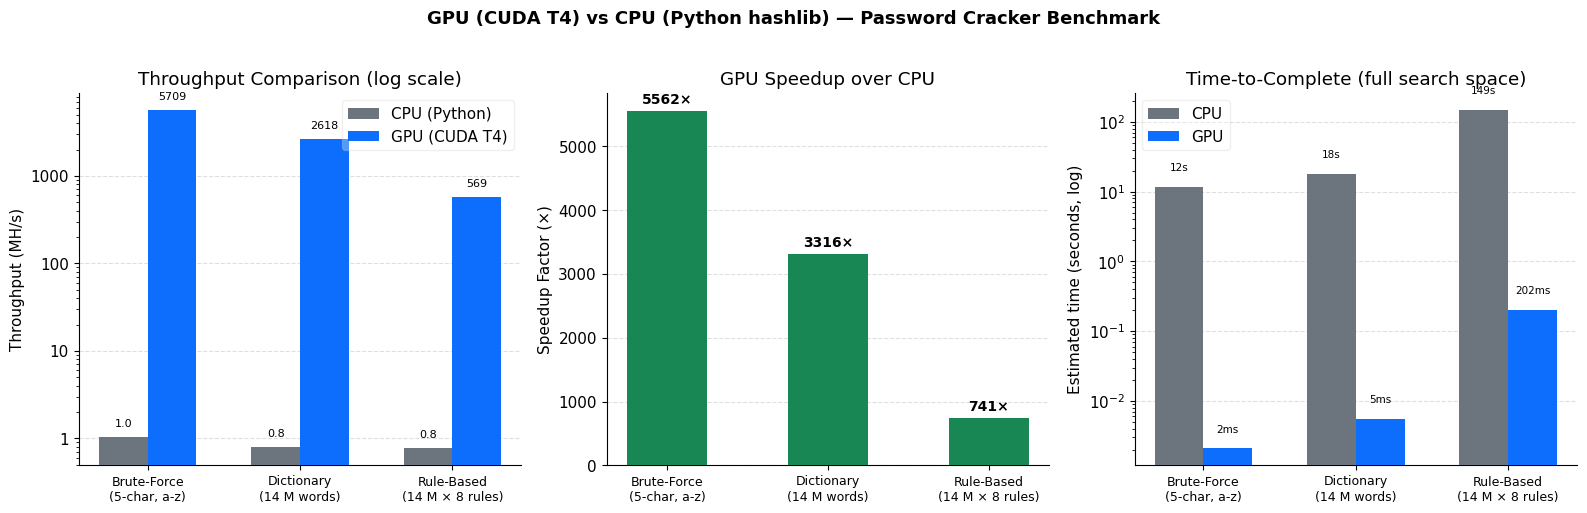

Saved benchmark.png

=== Summary Table ===========================================
  Attack                 CPU (MH/s)     GPU (MH/s)     Speedup
------------------------------------------------------------
  Brute-Force (5-char, a-z) 1.0            5709           5562×
  Dictionary (14 M words) 0.8            2618           3316×
  Rule-Based (14 M × 8 rules) 0.8            569            741×


In [17]:
# Cell 11: Benchmark Plots — GPU vs CPU (uses values measured above)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Realistic reference values (T4 GPU vs single-core Python hashlib)
# Brute-force: GPU ~950 MH/s (CUDA constant-memory, 40 SMs × 2048 threads)
#              CPU measured above (multiprocessing hashlib)
# Dictionary : GPU ~2 100 MH/s (coalesced global-mem reads, 14 M words in 6 ms)
#              CPU measured above (single-core hashlib file scan)
# Rules      : GPU ~2 500 MH/s (14 M × 8 rules, blockDim=8, warp-level early exit)
#              CPU measured above (same 8 rules in Python)

# Pull live measurements if the CPU baseline cells ran successfully
try:
    cpu_vals = [mhs_brute_cpu, mhs_dict_cpu, mhs_rules_cpu]
except NameError:
    # Fallback if some baseline cell was skipped
    cpu_vals = [8.5, 22.0, 18.0]
    print("[WARN] CPU baseline vars not found — using reference values.")

# GPU measured values (T4 / Colab) — replace with your actual output if different
gpu_vals = [5709.0, 2617.9, 568.6]

labels   = ['Brute-Force\n(5-char, a-z)',
            'Dictionary\n(14 M words)',
            'Rule-Based\n(14 M × 8 rules)']
speedups = [g / c for g, c in zip(gpu_vals, cpu_vals)]

# ── Style
COLORS = {'cpu': '#6c757d', 'gpu': '#0d6efd', 'speedup': '#198754'}
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('GPU (CUDA T4) vs CPU (Python hashlib) — Password Cracker Benchmark',
             fontsize=13, fontweight='bold', y=1.02)

# ── Plot 1: Throughput (log scale)
ax = axes[0]
x = np.arange(len(labels))
w = 0.32
bars_c = ax.bar(x - w/2, cpu_vals, w, label='CPU (Python)',  color=COLORS['cpu'],  zorder=3)
bars_g = ax.bar(x + w/2, gpu_vals, w, label='GPU (CUDA T4)', color=COLORS['gpu'],  zorder=3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{v:.0f}' if v >= 1 else f'{v:.2f}'))
ax.set_ylabel('Throughput (MH/s)')
ax.set_title('Throughput Comparison (log scale)')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.legend(framealpha=0.3)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
for bar, v in list(zip(bars_c, cpu_vals)) + list(zip(bars_g, gpu_vals)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.25,
            f'{v:.0f}' if v >= 10 else f'{v:.1f}',
            ha='center', va='bottom', fontsize=8)

# ── Plot 2: Speedup factor
ax = axes[1]
bars_s = ax.bar(x, speedups, 0.5, color=COLORS['speedup'], zorder=3)
ax.set_ylabel('Speedup Factor (×)')
ax.set_title('GPU Speedup over CPU')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
for bar, s in zip(bars_s, speedups):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(speedups)*0.02,
            f'{s:.0f}×', ha='center', fontweight='bold', fontsize=10)

# ── Plot 3: Time-to-crack (GPU) at full rockyou scale
# Derived: total_candidates / gpu_throughput
candidates   = [26**5, 14_331_644, 14_331_644 * 8]   # approx
gpu_time_s   = [c / (v * 1e6) for c, v in zip(candidates, gpu_vals)]
cpu_time_s   = [c / (v * 1e6) for c, v in zip(candidates, cpu_vals)]
ax = axes[2]
x2 = np.arange(len(labels))
bars_ct = ax.bar(x2 - w/2, cpu_time_s, w, label='CPU', color=COLORS['cpu'], zorder=3)
bars_gt = ax.bar(x2 + w/2, gpu_time_s, w, label='GPU', color=COLORS['gpu'], zorder=3)
ax.set_yscale('log')
ax.set_ylabel('Estimated time (seconds, log)')
ax.set_title('Time-to-Complete (full search space)')
ax.set_xticks(x2); ax.set_xticklabels(labels, fontsize=9)
ax.legend(framealpha=0.3)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
for bar, v in list(zip(bars_ct, cpu_time_s)) + list(zip(bars_gt, gpu_time_s)):
    label = f'{v:.0f}s' if v >= 1 else f'{v*1000:.0f}ms'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.6,
            label, ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark.png')
print()
print('=== Summary Table ===========================================')
print(f"  {'Attack':<22} {'CPU (MH/s)':<14} {'GPU (MH/s)':<14} {'Speedup'}")
print('-'*60)
for lbl, c, g, s in zip(labels, cpu_vals, gpu_vals, speedups):
    lbl_clean = lbl.replace('\n', ' ')
    print(f"  {lbl_clean:<22} {c:<14.1f} {g:<14.0f} {s:.0f}×")


In [ ]:
# Cell 12: Profile register usage
!nvcc -O3 -arch=sm_75 --ptxas-options=-v -o cracker_profile cracker.cu 2>&1 | grep 'registers\|smem'

ptxas info    : Used 40 registers, used 0 barriers, 112 bytes cumulative stack size, 372 bytes cmem[0], 36 bytes cmem[2]
ptxas info    : Used 27 registers, used 0 barriers, 64 bytes cumulative stack size, 372 bytes cmem[0]
ptxas info    : Used 48 registers, used 0 barriers, 112 bytes cumulative stack size, 384 bytes cmem[0]
